# Flood Probability Simulation — Coulantine River

## Context

The goal of this notebook is to simulate the behavior of a river over a one-year horizon, represented by the interval $t \in [0,1]$.

The idea is simple: rainfall events occur at random times $T_i$, and each event has an intensity $I_i$. After each rainfall event, the water level increases, then gradually decreases over time.

We want to know whether, during the year, the maximum river level exceeds a critical threshold $h_0$.

Rainfall arrivals are modeled by a non-homogeneous Poisson process with intensity

$$
\lambda(t)=\lambda_0\left(1+\alpha\sin(4\pi t)\right).
$$

This intensity introduces seasonality: some periods of the year are rainier than others.

The intensity of one rainfall event follows the density

$$
f_I(x)=\frac{c_I}{m+|x-x_0|^\eta}, \qquad x\geq 0.
$$

The water level at time $t$ is then defined by

$$
H(t)=\sum_i I_i r(t-T_i), \qquad r(t)=e^{-vt}\mathbf{1}_{t\geq0}.
$$

A flood occurs when $H_{\max}>h_0$, where $H_{\max}=\max_i H(T_i)$.

The final objective is to estimate, by Monte Carlo simulation,

$$
p^*=\mathbb{P}(H_{\max}>h_0).
$$


In [1]:
import numpy as np
import scipy.integrate as sci_int
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

rng = np.random.default_rng(seed=42)


## 1 · Model Parameters

We first set the parameters used in the simulation. They control the rainfall frequency, the distribution of rainfall intensities, and the speed at which water is absorbed.

The values below are used as a baseline case for testing the different simulation methods.


In [2]:
params = {
    "m"      : 2,    # height of the central plateau of f_I
    "x0"     : 3,    # mode of f_I
    "eta"    : 5,    # tail decay exponent
    "lambda0": 80,   # baseline rate of the Poisson process
    "alpha"  : 0.3,  # seasonality amplitude
    "v"      : 1,    # water absorption speed
    "h0"     : 200,  # flood threshold
}


## 2 · Simulation of Rainfall Intensities $\pi_I$

### 2.1 · Density and Normalizing Constant

The first step is to simulate the intensity $I_i$ of a rainfall event. We use a density centered around $x_0$, with tails that become heavier or lighter depending on the value of $\eta$.

The density is

$$
f_I(x)=\frac{c_I}{m+|x-x_0|^\eta}, \qquad x\geq0.
$$

The coefficient $c_I$ is the normalizing constant. It ensures that the integral of the density over $[0,+\infty)$ is equal to 1. Since this constant is not available in closed form here, we compute it numerically.


In [3]:
def f_I_nn(x, m, x0, eta):
    """Unnormalized kernel of f_I: 1 / (m + |x - x0|^eta)."""
    return 1.0 / (m + np.abs(x - x0)**eta)


def calc_c_I(params):
    """Normalizing constant c_I computed by numerical integration on [0, +∞)."""
    m, x0, eta = params["m"], params["x0"], params["eta"]
    val, _ = sci_int.quad(f_I_nn, 0, np.inf, args=(m, x0, eta))
    return 1.0 / val


def f_I(x, C_I, m, x0, eta):
    """Normalized density f_I(x) = c_I / (m + |x - x0|^eta)."""
    return C_I * f_I_nn(x, m, x0, eta)


# Computation and check
C_I = calc_c_I(params)
m, x0, eta = params["m"], params["x0"], params["eta"]

check, _ = sci_int.quad(f_I, 0, np.inf, args=(C_I, m, x0, eta))
print(f"Normalizing constant  c_I = {C_I:.6f}")
print(f"Check: ∫ f_I dx          = {check:.6f}  (should be close to 1)")


Normalizing constant  c_I = 0.816435
Check: ∫ f_I dx          = 1.000000  (should be close to 1)


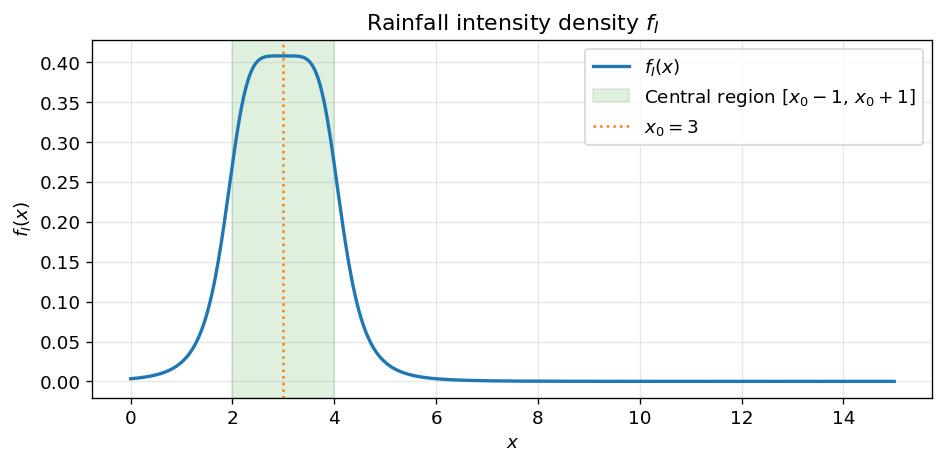

In [4]:
# Visualization of f_I
x_grid = np.linspace(0, 15, 800)
y_grid = f_I(x_grid, C_I, m, x0, eta)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_grid, y_grid, 'C0', lw=2, label=r"$f_I(x)$")
ax.axvspan(x0 - 1, x0 + 1, alpha=0.15, color='C2', label=r"Central region $[x_0-1,\,x_0+1]$")
ax.axvline(x0, color='C1', ls=':', lw=1.5, label=f"$x_0 = {x0}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$f_I(x)$")
ax.set_title(r"Rainfall intensity density $f_I$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 2.2 · Splitting the Density into Two Regions

The density $f_I$ is not very convenient to simulate directly. We split it into two parts:

- a central region around $x_0$, where the density is fairly regular;
- the tails, where large values are rare but important.

Let $p_c$ denote the probability mass of the central region $[x_0-1,x_0+1]$.

In practice, we first draw a Bernoulli variable with parameter $p_c$. If it is equal to 1, we simulate in the central region. Otherwise, we simulate in the tails.

This split makes the simulation more efficient than using one rejection method over the entire domain.


In [5]:
def central_mass(params, C_I):
    """p_c = ∫_{x0-1}^{x0+1} f_I(x) dx, the probability mass of the central region."""
    m, x0, eta = params["m"], params["x0"], params["eta"]
    val, _ = sci_int.quad(f_I, x0 - 1, x0 + 1, args=(C_I, m, x0, eta))
    return val


p_c = central_mass(params, C_I)
print(f"Central-region mass  p_c = {p_c:.6f}")
print(f"Tail mass        1 - p_c = {1 - p_c:.6f}")


Central-region mass  p_c = 0.762313
Tail mass        1 - p_c = 0.237687


### 2.3 · Simulation in the Central Region

On the interval $[x_0-1,x_0+1]$, the density is bounded in a simple way. We can therefore use rejection sampling with a uniform proposal.

The idea is to propose a value $X$ uniformly in the central region, and then accept it with probability proportional to $f_I(X)$.

The bound used is

$$
f_I(x)\leq \frac{c_I}{m}, \qquad x\in[x_0-1,x_0+1].
$$

This method is fast in the central region because it avoids proposing too many values that will be rejected.


In [6]:
def simulate_center(n, C_I, params, rng):
    """
    Simulate n values from f_I restricted to [x0-1, x0+1]
    using uniform rejection sampling.

    Returns an array with shape (n,).
    """
    m, x0, eta = params["m"], params["x0"], params["eta"]
    lower_bound, upper_bound = x0 - 1, x0 + 1
    M_c = C_I / m  # upper bound of f_I on [x0-1, x0+1]

    result = np.empty(n)
    accepted = 0

    while accepted < n:
        batch = max(2 * (n - accepted), 100)
        X = rng.uniform(lower_bound, upper_bound, batch)
        U = rng.uniform(0, M_c, batch)

        accepted_mask = U <= f_I(X, C_I, m, x0, eta)
        new_samples = X[accepted_mask]

        end = min(accepted + len(new_samples), n)
        result[accepted:end] = new_samples[:end - accepted]
        accepted = end

    return result


### 2.4 · Simulation in the Tails

Outside the central region, the density has heavier tails. A uniform proposal would be inefficient because it would often miss the relevant range of values.

We therefore use a Cauchy distribution as the proposal distribution. This is a natural choice because the Cauchy distribution also has heavy tails.

The proposal is centered at $x_0$ with scale parameter $\sqrt{m}$, and we only keep the values that fall in the tail region.


In [7]:
def cauchy_tail(n, x0, scale, rng):
    """
    Simulate n values from a Cauchy(x0, scale) distribution,
    restricted to the tail region [0, +∞) \ [x0-1, x0+1].
    """
    result = np.empty(n)
    accepted = 0

    while accepted < n:
        batch = max(4 * (n - accepted), 100)
        X = rng.standard_cauchy(batch) * scale + x0

        # Keep only values in the tail region.
        tail_values = X[(X >= 0) & ((X < x0 - 1) | (X > x0 + 1))]

        end = min(accepted + len(tail_values), n)
        result[accepted:end] = tail_values[:end - accepted]
        accepted = end

    return result


def simulate_tail(n, C_I, params, rng):
    """
    Simulate n values from f_I restricted to the tails
    using Cauchy rejection sampling with proposal Cauchy(x0, sqrt(m)).

    Returns an array with shape (n,).
    """
    m, x0, eta = params["m"], params["x0"], params["eta"]
    scale = np.sqrt(m)  # scale of the Cauchy proposal
    M_q = scale         # upper bound of f_I / g

    result = np.empty(n)
    accepted = 0

    while accepted < n:
        batch = max(2 * (n - accepted), 100)
        X = cauchy_tail(batch, x0, scale, rng)
        U = rng.uniform(0, M_q, len(X))

        # g(x) is the Cauchy(x0, scale) density; scipy uses loc/scale.
        ratio = f_I(X, C_I, m, x0, eta) / stats.cauchy.pdf(X, loc=x0, scale=scale)
        accepted_mask = U <= ratio
        new_samples = X[accepted_mask]

        end = min(accepted + len(new_samples), n)
        result[accepted:end] = new_samples[:end - accepted]
        accepted = end

    return result


<>:4: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:4: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
C:\Users\diaba\AppData\Local\Temp\ipykernel_36280\1310077650.py:4: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  restricted to the tail region [0, +∞) \ [x0-1, x0+1].


### 2.5 · Function `simulate_intensities`

We can now combine the two previous methods into a single function.

The function `simulate_intensities` first decides which region each intensity should come from. It then applies the appropriate method: uniform rejection sampling for the central region, and Cauchy rejection sampling for the tails.

The histogram below is used to check that the simulated values match the theoretical density.


In [8]:
def simulate_intensities(n, params, rng):
    """
    Simulate n independent draws from the rainfall intensity distribution π_I.

    Mixture algorithm:
      - Z_i ~ Bernoulli(p_c)
      - if Z_i = 1: central simulation with uniform rejection sampling
      - if Z_i = 0: tail simulation with Cauchy rejection sampling

    Args:
        n      : number of values to simulate
        params : model parameter dictionary
        rng    : NumPy random generator

    Returns:
        np.ndarray with shape (n,)
    """
    C_I = calc_c_I(params)
    p_c = central_mass(params, C_I)

    Z = rng.random(n) <= p_c   # True means central region
    K = Z.sum()                # number of points in the central region

    result = np.empty(n)

    if K > 0:
        result[Z] = simulate_center(K, C_I, params, rng)

    if K < n:
        result[~Z] = simulate_tail(n - K, C_I, params, rng)

    return result


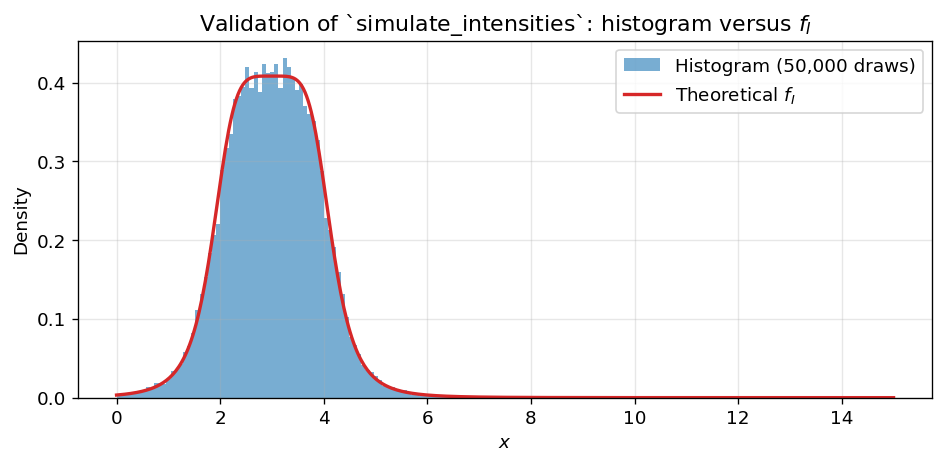

In [9]:
# Check: histogram versus theoretical density
n_test = 50_000
sample = simulate_intensities(n_test, params, rng)

x_grid = np.linspace(0, 15, 500)
C_I = calc_c_I(params)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample, bins=150, density=True, color='C0', alpha=0.6, label=f"Histogram ({n_test:,} draws)")
ax.plot(x_grid, f_I(x_grid, C_I, m, x0, eta), 'C3', lw=2, label=r"Theoretical $f_I$")
ax.set_xlabel("$x$")
ax.set_ylabel("Density")
ax.set_title(r"Validation of `simulate_intensities`: histogram versus $f_I$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3 · Simulation of Rainfall Dates

### 3.1 · Seasonal Intensity

Rainfall dates are modeled by a non-homogeneous Poisson process. This means that the frequency of rainfall depends on time.

We use the intensity

$$
\lambda(t)=\lambda_0\left(1+\alpha\sin(4\pi t)\right), \qquad t\in[0,1].
$$

The parameter $\lambda_0$ represents the average number of rainfall events during the year. The parameter $\alpha$ controls the strength of the seasonality.

Since the integral of the sine term over $[0,1]$ is zero, the average number of rainfall events remains equal to $\lambda_0$.

### 3.2 · Thinning Method

To simulate this process, we use the thinning method.

We first simulate a homogeneous Poisson process with a larger intensity, here $2\lambda_0$. Then, each proposed date is kept with a probability depending on $\lambda(t)$.

This method produces rainfall dates whose distribution follows the desired seasonal intensity.


In [10]:
def lambda_t(t, lambda0, alpha):
    """Poisson process intensity: λ(t) = λ0 (1 + α sin(4πt))."""
    return lambda0 * (1 + alpha * np.sin(4 * np.pi * t))


def simulate_rain_dates(params, rng):
    """
    Simulate rainfall arrival dates on [0, 1]
    using the thinning method.

    Returns:
        np.ndarray of rainfall dates T_i in [0, 1]. The array may be empty.
    """
    lambda0, alpha = params["lambda0"], params["alpha"]
    Lambda_max = 2 * lambda0  # upper bound for λ(t)

    dates = []
    t = 0.0

    while True:
        t += rng.exponential(1.0 / Lambda_max)  # homogeneous inter-arrival time

        if t > 1.0:
            break

        # Thinning step: keep the proposed date with probability λ(t) / Λ_max.
        if rng.random() <= lambda_t(t, lambda0, alpha) / Lambda_max:
            dates.append(t)

    return np.array(dates)


λ0 (theoretical value) = 80
Simulated mean count   = 79.92
Simulated variance     = 79.25  (should be close to λ0 = 80)


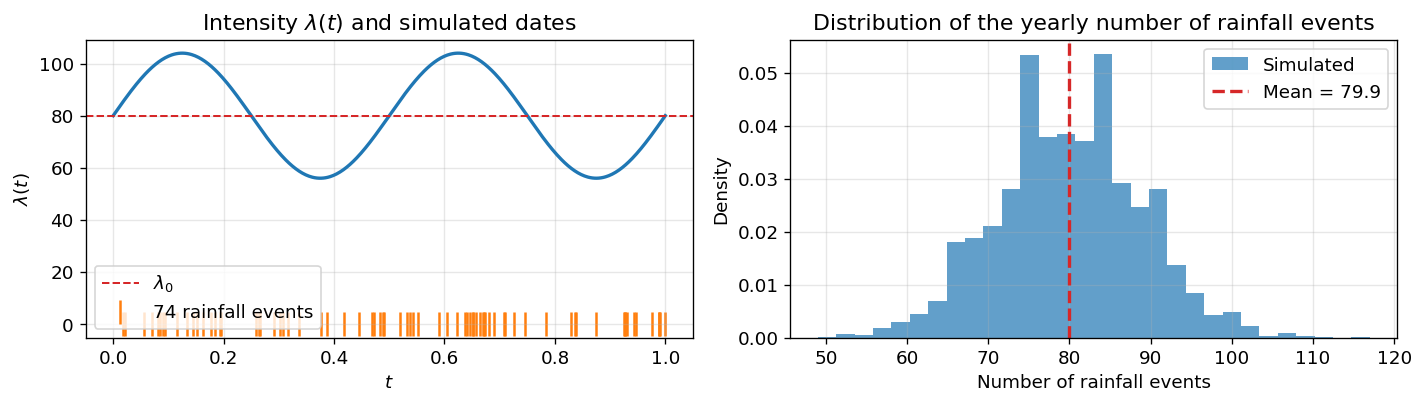

In [11]:
# Validation: average number of arrivals should be close to λ0
n_rep = 5_000
counts = np.array([len(simulate_rain_dates(params, rng)) for _ in range(n_rep)])

print(f"λ0 (theoretical value) = {params['lambda0']}")
print(f"Simulated mean count   = {counts.mean():.2f}")
print(f"Simulated variance     = {counts.var():.2f}  (should be close to λ0 = {params['lambda0']})")

# Visualization of one realization
t_ex = simulate_rain_dates(params, rng)
t_grid = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(t_grid, lambda_t(t_grid, params["lambda0"], params["alpha"]), 'C0', lw=2)
axes[0].axhline(params["lambda0"], color='C3', ls='--', lw=1.2, label=r"$\lambda_0$")
axes[0].scatter(t_ex, np.zeros_like(t_ex), marker='|', s=200, color='C1', label=f"{len(t_ex)} rainfall events")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel(r"$\lambda(t)$")
axes[0].set_title(r"Intensity $\lambda(t)$ and simulated dates")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(counts, bins=30, density=True, color='C0', alpha=0.7, label="Simulated")
axes[1].axvline(counts.mean(), color='C3', lw=2, ls='--', label=f"Mean = {counts.mean():.1f}")
axes[1].set_xlabel("Number of rainfall events")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of the yearly number of rainfall events")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4 · Water Level Model

Once the rainfall dates $T_i$ and intensities $I_i$ have been simulated, we can compute the water level of the river.

Each rainfall event increases the water level, and its effect then decreases exponentially over time. The total water level is the sum of all past rainfall contributions:

$$
H(t)=\sum_{i=1}^{n} I_i e^{-v(t-T_i)}\mathbf{1}_{t\geq T_i}.
$$

The parameter $v$ measures the absorption speed. The larger $v$ is, the faster water disappears after rainfall.

We do not need to evaluate $H(t)$ at every time. Between two rainfall events, the water level decreases. Therefore, the maximum can only be reached at a rainfall time. We can compute

$$
H_{\max}=\max_i H(T_i).
$$


In [12]:
def r(t, v):
    """Impulse response: r(t) = exp(-v*t) * 1_{t>=0}."""
    return np.where(t >= 0, np.exp(-v * t), 0.0)


def H_max(Ti, Ii, v):
    """
    Compute max_i H(T_i) for a given rainfall scenario.

    H(T_i) = sum_j I_j * r(T_i - T_j)

    Args:
        Ti : np.ndarray with shape (n,), rainfall dates
        Ii : np.ndarray with shape (n,), rainfall intensities
        v  : water absorption speed

    Returns:
        float, maximum water level
    """
    if len(Ti) == 0:
        return 0.0

    # Delay matrix: diff[i, j] = T_i - T_j.
    diff = Ti[:, None] - Ti[None, :]  # (n, n)

    # H(T_i) = sum_j I_j * r(T_i - T_j).
    # Terms with j > i correspond to negative delays and are filtered by r().
    H_vals = (Ii[None, :] * r(diff, v)).sum(axis=1)  # (n,)

    return H_vals.max()


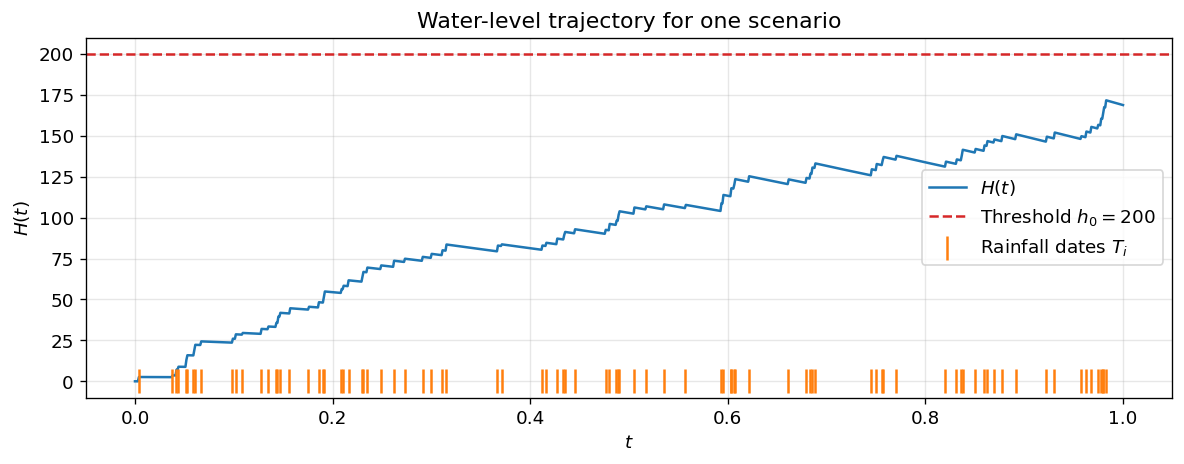

Number of rainfall events n = 89
Maximum water level Hmax    = 171.74  (threshold h0 = 200)


In [13]:
# Visualization of one water-level scenario
Ti_ex = simulate_rain_dates(params, rng)
Ii_ex = simulate_intensities(len(Ti_ex), params, rng)
v = params["v"]

t_grid = np.linspace(0, 1, 1000)
H_traj = np.array([
    (Ii_ex * r(t - Ti_ex, v)).sum()
    for t in t_grid
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_grid, H_traj, 'C0', lw=1.5, label="$H(t)$")
ax.axhline(params["h0"], color='C3', ls='--', lw=1.5, label=f"Threshold $h_0 = {params['h0']}$")
ax.scatter(Ti_ex, np.zeros_like(Ti_ex), marker='|', s=200, color='C1', zorder=5, label="Rainfall dates $T_i$")
ax.set_xlabel("$t$")
ax.set_ylabel("$H(t)$")
ax.set_title("Water-level trajectory for one scenario")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of rainfall events n = {len(Ti_ex)}")
print(f"Maximum water level Hmax    = {H_max(Ti_ex, Ii_ex, v):.2f}  (threshold h0 = {params['h0']})")


## 5 · Monte Carlo Estimation of $p^*$

### 5.1 · Monte Carlo Estimator

We want to estimate the probability that a flood occurs during the year.

To do this, we repeat the full experiment many times: simulate rainfall dates, simulate rainfall intensities, compute the maximum water level, and check whether the threshold $h_0$ is exceeded.

If $Z_k$ denotes the flood indicator for simulation $k$, then the Monte Carlo estimator is

$$
\hat p_N^*=\frac{1}{N}\sum_{k=1}^N Z_k.
$$

As $N$ increases, this estimator stabilizes around the true probability $p^*$. We can also build a 95% confidence interval:

$$
\hat p_N^* \pm 1.96\sqrt{\frac{\hat p_N^*(1-\hat p_N^*)}{N}}.
$$


In [14]:
def one_flood_event(params, rng):
    """
    Simulate one yearly scenario and return the flood indicator.

    Returns:
        1 if H_max > h0, otherwise 0
    """
    Ti = simulate_rain_dates(params, rng)

    if len(Ti) == 0:
        return 0

    Ii = simulate_intensities(len(Ti), params, rng)

    return int(H_max(Ti, Ii, params["v"]) > params["h0"])


def estimate_p_star(n_simul, params, rng):
    """
    Estimate p* = P(H_max > h0) using standard Monte Carlo.

    Args:
        n_simul : number of simulations
        params  : model parameters
        rng     : NumPy random generator

    Returns:
        dictionary with keys: p, ci_low, ci_high, half_width
    """
    indicators = np.array([one_flood_event(params, rng) for _ in range(n_simul)])

    p = indicators.mean()
    half_width = 1.96 * np.sqrt(p * (1 - p) / n_simul)

    return {
        "p": p,
        "ci_low": p - half_width,
        "ci_high": p + half_width,
        "half_width": half_width,
    }


In [15]:
# Estimation of p*
print("Estimating p* using standard Monte Carlo...")

n_simul = 5_000
res = estimate_p_star(n_simul, params, rng)

print(f"\n{'─'*45}")
print(f"  Simulations         : {n_simul:,}")
print(f"  p̂*                 : {res['p']:.6f}")
print(f"  95% CI              : [{res['ci_low']:.6f},  {res['ci_high']:.6f}]")
print(f"  Half-width          : {res['half_width']:.6f}")
print(f"{'─'*45}")


Estimating p* using standard Monte Carlo...

─────────────────────────────────────────────
  Simulations         : 5,000
  p̂*                 : 0.005000
  95% CI              : [0.003045,  0.006955]
  Half-width          : 0.001955
─────────────────────────────────────────────


### 5.2 · Convergence of the Estimator

We now plot the estimate of $p^*$ as a function of the number of simulations.

The goal is to visually check that the estimator stabilizes as $N$ increases. The confidence interval should also become narrower, which reflects a reduction in uncertainty.


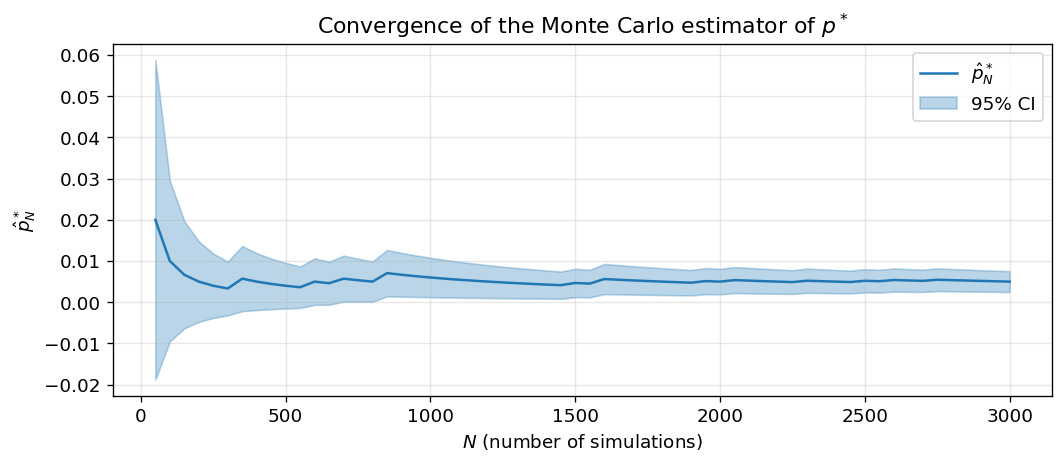

In [16]:
n_total = 3_000
all_indicators = np.array([one_flood_event(params, rng) for _ in range(n_total)])

N_vals = np.arange(50, n_total + 1, 50)
cumulative_p = np.array([all_indicators[:n].mean() for n in N_vals])
half_width = 1.96 * np.sqrt(cumulative_p * (1 - cumulative_p) / N_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(N_vals, cumulative_p, 'C0', lw=1.5, label=r"$\hat{p}^*_N$")
ax.fill_between(
    N_vals,
    cumulative_p - half_width,
    cumulative_p + half_width,
    alpha=0.3,
    color='C0',
    label="95% CI",
)
ax.set_xlabel("$N$ (number of simulations)")
ax.set_ylabel(r"$\hat{p}^*_N$")
ax.set_title("Convergence of the Monte Carlo estimator of $p^*$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6 · Importance Sampling `estimate_p_star_IS`

### 6.1 · Why Use Another Method?

When the event of interest becomes rare, standard Monte Carlo can become very slow. For example, if the flood probability is very small, most simulations produce no flood.

In that case, the estimator contains many zeros and very little useful information. A very large number of simulations is then needed to obtain a stable estimate.

The idea of importance sampling is to simulate under a modified probability law that produces floods more often, and then correct the bias using a likelihood weight.

### 6.2 · Change of Measure

To make floods more frequent, we increase the rainfall intensity. Instead of simulating with $\lambda(t)$, we simulate with

$$
\lambda'(t)=\lambda(t)+\delta, \qquad \delta>0.
$$

With this new intensity, there are more rainfall events on average. Flood scenarios therefore appear more often.

### 6.3 · Correction Weight

Since we no longer simulate under the true probability law, each scenario must be corrected by a weight. This weight is the ratio between the likelihood of the scenario under the true law and its likelihood under the modified law.

For a scenario with $n$ rainfall events at dates $T_1,\ldots,T_n$, the weight is

$$
w_n=e^{\delta}\prod_{i=1}^n\frac{\lambda(T_i)}{\lambda(T_i)+\delta}.
$$

The $+\delta$ in the exponential is important: it comes from the ratio between the two integrated intensities over the year.

If $\delta$ is too large, the weights can become extremely small and the estimator becomes unstable. In practice, $\delta$ must be large enough to encourage floods, but not so large that the weights degenerate.

### 6.4 · Importance Sampling Estimator

The final estimator is the average of the flood indicators multiplied by the weight $w_n$:

$$
\hat p^*_{IS}=\frac{1}{N}\sum_{k=1}^N \mathbf{1}_{\{H_{\max}^{(k)}>h_0\}}w_{n_k}.
$$

This method is unbiased when the weights are correctly computed. It can be much more efficient than standard Monte Carlo for small probabilities.


In [17]:
def simulate_tilted_rain_dates(delta, params, rng):
    """
    Simulate rainfall dates under the tilted process with intensity
    λ'(t) = λ(t) + δ, using thinning.

    Upper bound: Λ'_max = λ0*(1+α) + δ <= 2*λ0 + δ.

    Returns:
        np.ndarray of rainfall dates T_i
    """
    lambda0, alpha = params["lambda0"], params["alpha"]
    Lambda_max_prime = 2 * lambda0 + delta  # upper bound for λ'(t)

    dates = []
    t = 0.0

    while True:
        t += rng.exponential(1.0 / Lambda_max_prime)

        if t > 1.0:
            break

        lam_prime_t = lambda_t(t, lambda0, alpha) + delta

        if rng.random() <= lam_prime_t / Lambda_max_prime:
            dates.append(t)

    return np.array(dates)


def RN_weight(Ti, delta, params):
    """
    Compute the Radon-Nikodym weight dP/dP' for one scenario.

    Likelihood-ratio derivation for a Poisson process:
      w_n = L(λ; T) / L(λ'; T)
          = exp(Λ' - Λ) · ∏ λ(T_i)/λ'(T_i)
          = exp(+δ)     · ∏ λ(T_i)/(λ(T_i)+δ)

    The computation is done in log-space to avoid overflow from exp(+δ)
    and underflow from products close to zero.
    """
    lambda0, alpha = params["lambda0"], params["alpha"]

    if len(Ti) == 0:
        # Empty product = 1, so w = exp(+δ).
        return float(np.exp(delta))

    lam = lambda_t(Ti, lambda0, alpha)                 # λ(T_i)
    log_w = delta + np.sum(np.log(lam / (lam + delta)))  # log w = +δ + sum log ratio

    return float(np.exp(log_w))


def one_IS_contribution(delta, params, rng):
    """
    Simulate one draw under P' and correct it using the Radon-Nikodym weight.

    Returns:
        float, flood indicator multiplied by the likelihood weight
    """
    Ti = simulate_tilted_rain_dates(delta, params, rng)

    if len(Ti) == 0:
        return 0.0

    Ii = simulate_intensities(len(Ti), params, rng)

    if H_max(Ti, Ii, params["v"]) > params["h0"]:
        return RN_weight(Ti, delta, params)

    return 0.0


def estimate_p_star_IS(n_simul, delta, params, rng):
    """
    Estimate p* using importance sampling with tilted intensity λ' = λ + δ.

    Args:
        n_simul : number of simulations
        delta   : constant increase of the Poisson rate, preferably δ << λ0
        params  : model parameters
        rng     : NumPy random generator

    Returns:
        dictionary with p, variance, ci_low, ci_high, half_width
    """
    weights = np.array([one_IS_contribution(delta, params, rng) for _ in range(n_simul)])

    p = weights.mean()
    var = weights.var(ddof=1)
    half_width = 1.96 * np.sqrt(var / n_simul)

    return {
        "p": p,
        "var": var,
        "ci_low": p - half_width,
        "ci_high": p + half_width,
        "half_width": half_width,
    }


In [18]:

delta = 10
n_simul = 5_000

print(f"Estimating p* using importance sampling (δ = {delta})...")

res_IS = estimate_p_star_IS(n_simul, delta, params, rng)

print(f"\n{'─'*50}")
print(f"  δ (rate increase)    : {delta}")
print(f"  Simulations          : {n_simul:,}")
print(f"  p̂* (IS)             : {res_IS['p']:.6f}")
print(f"  95% CI               : [{res_IS['ci_low']:.6f},  {res_IS['ci_high']:.6f}]")
print(f"  Half-width           : {res_IS['half_width']:.6f}")
print(f"  Estimated variance   : {res_IS['var']:.6e}")
print(f"{'─'*50}")


Estimating p* using importance sampling (δ = 10)...

──────────────────────────────────────────────────
  δ (rate increase)    : 10
  Simulations          : 5,000
  p̂* (IS)             : 0.005880
  95% CI               : [0.005164,  0.006597]
  Half-width           : 0.000716
  Estimated variance   : 6.680573e-04
──────────────────────────────────────────────────


### 6.5 · Comparing Standard Monte Carlo and Importance Sampling

We now compare the two methods using the same order of magnitude of simulations.

The important point is not only the estimated probability, but also the relative precision. A method is better if it gives a smaller uncertainty for the same computational budget.


Method                       Mean          Std     CV (%)
─────────────────────────────────────────────────────────
Standard Monte Carlo      0.00687      0.00360      52.5%
Importance sampling       0.00613      0.00117      19.1%


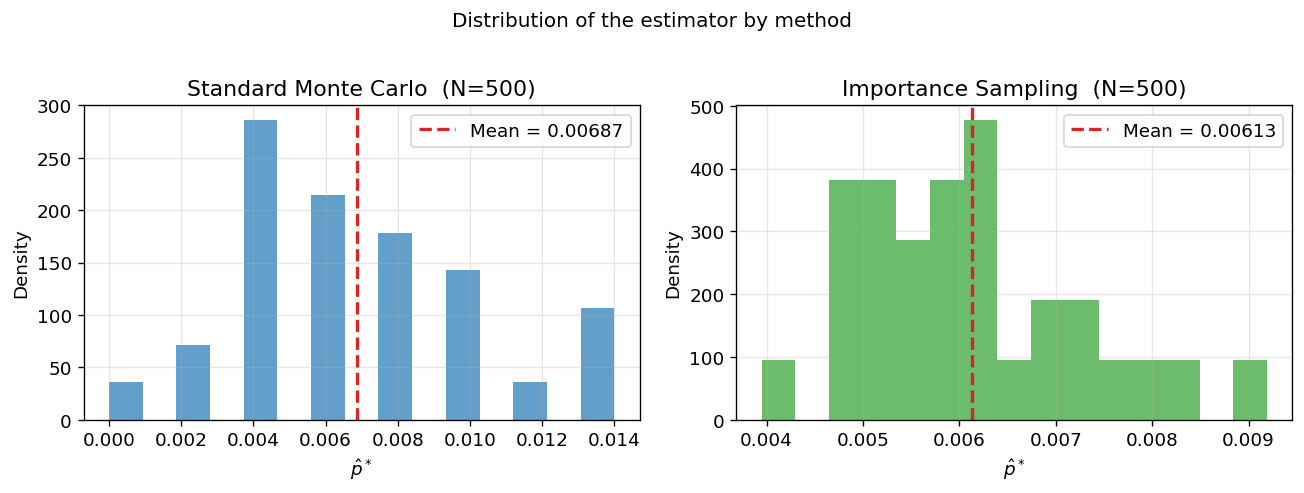

In [19]:
n_rep = 30     # independent repetitions for each method
n_budget = 500  # budget per repetition

p_mc = np.array([estimate_p_star(n_budget, params, rng)["p"] for _ in range(n_rep)])
p_is = np.array([estimate_p_star_IS(n_budget, delta, params, rng)["p"] for _ in range(n_rep)])

print(f"{'Method':<22} {'Mean':>10} {'Std':>12} {'CV (%)':>10}")
print("─" * 57)

for name, estimates in [("Standard Monte Carlo", p_mc), ("Importance sampling", p_is)]:
    mu = estimates.mean()
    sig = estimates.std()
    cv = sig / mu * 100 if mu > 0 else float("nan")
    print(f"{name:<22} {mu:>10.5f} {sig:>12.5f} {cv:>9.1f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, estimates, name, color in [
    (axes[0], p_mc, "Standard Monte Carlo", 'C0'),
    (axes[1], p_is, "Importance Sampling", 'C2'),
]:
    ax.hist(estimates, bins=15, color=color, alpha=0.7, density=True)
    ax.axvline(estimates.mean(), color='C3', lw=2, ls='--', label=f"Mean = {estimates.mean():.5f}")
    ax.set_xlabel(r"$\hat{p}^*$")
    ax.set_ylabel("Density")
    ax.set_title(name + f"  (N={n_budget})")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Distribution of the estimator by method", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 7 · Control Variate : Variance Reduction

### 7.1 · Principle

Another way to reduce the variance is to use a control variate.

The idea is to find a quantity $C$ computed during each simulation, correlated with the flood event, and whose expectation is known. We can then correct the Monte Carlo estimator by removing the part explained by this variable.

Let $Z_k=\mathbf{1}_{\{H_{\max}^{(k)}>h_0\}}$. The corrected estimator is

$$
\hat p^*_{CV}=\bar Z-b(\bar C-\mathbb{E}[C]).
$$

The coefficient $b$ is chosen to reduce the variance as much as possible. In practice, it is estimated from the simulations.

### 7.2 · Choice of the Control Variate

We choose the total rainfall intensity over the year as the control variate:

$$
C=\sum_{i=1}^{N_T} I_i.
$$

This choice is natural: when the total rainfall intensity is large, the maximum river level is more likely to be high. The variable $C$ is therefore positively correlated with the flood indicator.

The advantage is that the expectation of $C$ can be computed simply. Since the number of rainfall events $N_T$ is independent of the intensities and $\mathbb{E}[N_T]=\lambda_0$, we get

$$
\mathbb{E}[C]=\lambda_0\mu_I,
$$

where $\mu_I=\mathbb{E}[I]$ is computed numerically from the density $f_I$.

### 7.3 · Practical Estimation

The optimal coefficient $b$ depends on the covariance between $Z$ and $C$. Since this covariance is not known in advance, we estimate it directly from the simulated sample.

This correction does not change the simulation law. It simply uses additional information available in each simulation to make the estimate more stable.


In [20]:
def analytic_mu_I(params):
    """E[I] = c_I * ∫_0^∞ x / (m + |x-x0|^eta) dx, computed by numerical integration."""
    C_I = calc_c_I(params)
    m, x0, eta = params["m"], params["x0"], params["eta"]

    val, _ = sci_int.quad(lambda x: x / (m + np.abs(x - x0)**eta), 0, np.inf)

    return C_I * val


def one_control_variate_simulation(params, rng):
    """
    One Monte Carlo draw returning (Z_k, C_k).

      Z_k = 1_{H_max > h0}, the flood indicator
      C_k = Σ I_i, the control variate based on total rainfall intensity
    """
    Ti = simulate_rain_dates(params, rng)

    if len(Ti) == 0:
        return 0, 0.0

    Ii = simulate_intensities(len(Ti), params, rng)
    z = int(H_max(Ti, Ii, params["v"]) > params["h0"])
    c = float(Ii.sum())

    return z, c


def estimate_p_star_CV(n_simul, params, rng):
    """
    Estimate p* = P(H_max > h0) using the control variate C = ΣI_i.

    Wald's formula: E[C] = λ0 · E[I] = λ0 · μ_I, which is known analytically.
    Estimated optimal coefficient: b_hat = Cov(Z,C) / Var(C).
    Corrected estimator: p_CV = mean(Z) - b_hat * (mean(C) - E[C]).
    Variance reduction factor: (1 - ρ²).

    Returns:
        dictionary with p, var, ci_low, ci_high, half_width, b_opt, rho, reduction_pct
    """
    mu_I_val = analytic_mu_I(params)
    E_C = params["lambda0"] * mu_I_val  # Wald: E[C] = λ0 · E[I]

    res = [one_control_variate_simulation(params, rng) for _ in range(n_simul)]
    Z = np.array([r[0] for r in res], dtype=float)
    C = np.array([r[1] for r in res])

    # Optimal coefficient estimated from the sample.
    b_hat = np.cov(Z, C)[0, 1] / C.var(ddof=1)

    # Control-variate corrected estimator.
    Z_corr = Z - b_hat * (C - E_C)

    p = Z_corr.mean()
    var_CV = Z_corr.var(ddof=1)
    half_width = 1.96 * np.sqrt(var_CV / n_simul)
    rho = float(np.corrcoef(Z, C)[0, 1])

    return {
        "p": p,
        "var": var_CV,
        "ci_low": p - half_width,
        "ci_high": p + half_width,
        "half_width": half_width,
        "b_opt": b_hat,
        "mu_I": mu_I_val,
        "E_C": E_C,
        "rho": rho,
        "reduction_pct": (1.0 - rho**2) * 100.0,
    }


In [21]:
# Analytical computation of μ_I and E[C]
mu_I_val = analytic_mu_I(params)

print(f"μ_I = E[I]       = {mu_I_val:.6f}")
print(f"E[C] = λ0 · μ_I = {params['lambda0']} × {mu_I_val:.6f} = {params['lambda0'] * mu_I_val:.4f}")

# Estimation using the control variate
n_simul = 5_000
print(f"\nEstimating p* using the control variate method (N = {n_simul:,})...")

res_CV = estimate_p_star_CV(n_simul, params, rng)

print(f"\n{'─'*55}")
print(f"  Simulations          : {n_simul:,}")
print(f"  p̂* (CV)             : {res_CV['p']:.6f}")
print(f"  95% CI               : [{res_CV['ci_low']:.6f},  {res_CV['ci_high']:.6f}]")
print(f"  Half-width           : {res_CV['half_width']:.6f}")
print(f"  Coefficient b̂*      : {res_CV['b_opt']:.6f}")
print(f"  Correlation ρ̂(Z, C) : {res_CV['rho']:.4f}")
print(f"  Variance reduction   : {res_CV['reduction_pct']:.1f}%")
print(f"{'─'*55}")


μ_I = E[I]       = 3.010048
E[C] = λ0 · μ_I = 80 × 3.010048 = 240.8039

Estimating p* using the control variate method (N = 5,000)...

───────────────────────────────────────────────────────
  Simulations          : 5,000
  p̂* (CV)             : 0.006639
  95% CI               : [0.004457,  0.008821]
  Half-width           : 0.002182
  Coefficient b̂*      : 0.000675
  Correlation ρ̂(Z, C) : 0.2344
  Variance reduction   : 94.5%
───────────────────────────────────────────────────────


c:\Users\diaba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\diaba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Method                             Mean        Std    CV (%)
────────────────────────────────────────────────────────────
Standard MC                     0.00667    0.00348     52.2%
Imp. Sampling (δ=10)            0.00605    0.00126     20.8%
Control variate (ΣI_i)          0.00522    0.00274     52.5%


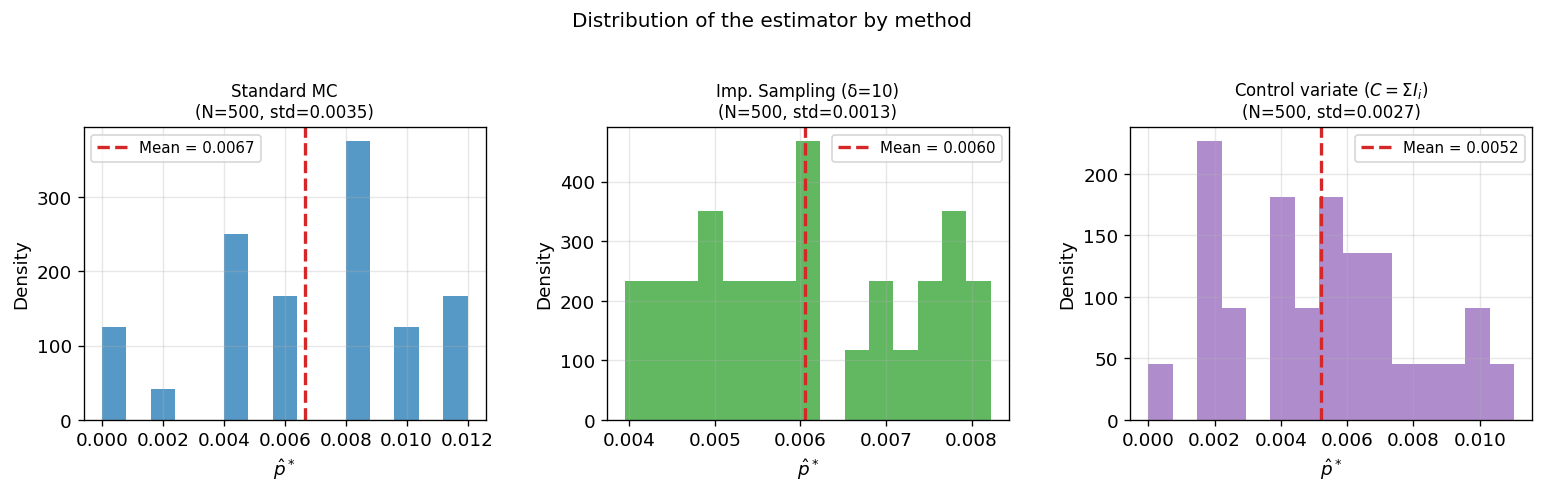

In [22]:
# Comparison of the three methods
n_rep = 30
n_budget = 500

p_mc = np.array([estimate_p_star(n_budget, params, rng)["p"] for _ in range(n_rep)])
p_is = np.array([estimate_p_star_IS(n_budget, delta, params, rng)["p"] for _ in range(n_rep)])
p_cv = np.array([estimate_p_star_CV(n_budget, params, rng)["p"] for _ in range(n_rep)])

print(f"{'Method':<28} {'Mean':>10} {'Std':>10} {'CV (%)':>9}")
print("─" * 60)

for name, estimates in [
    ("Standard MC", p_mc),
    (f"Imp. Sampling (δ={delta})", p_is),
    ("Control variate (ΣI_i)", p_cv),
]:
    mu = estimates.mean()
    sig = estimates.std()
    cv = sig / mu * 100 if mu > 1e-10 else float("nan")
    print(f"{name:<28} {mu:>10.5f} {sig:>10.5f} {cv:>8.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, estimates, name, color in [
    (axes[0], p_mc, "Standard MC", 'C0'),
    (axes[1], p_is, f"Imp. Sampling (δ={delta})", 'C2'),
    (axes[2], p_cv, r"Control variate ($C=\Sigma I_i$)", 'C4'),
]:
    ax.hist(estimates, bins=15, color=color, alpha=0.75, density=True)
    ax.axvline(estimates.mean(), color='C3', lw=2, ls='--', label=f"Mean = {estimates.mean():.4f}")
    ax.set_xlabel(r"$\hat{p}^*$")
    ax.set_ylabel("Density")
    ax.set_title(f"{name}\n(N={n_budget}, std={estimates.std():.4f})", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Distribution of the estimator by method", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 8 · Summary

This notebook builds a complete simulation framework for estimating the flood probability of a river.

The main steps are:

- simulate rainfall intensities with a suitable rejection sampling method;
- simulate rainfall dates by thinning a non-homogeneous Poisson process;
- compute the maximum river level;
- estimate the flood probability using Monte Carlo simulation;
- improve the estimation using importance sampling and a control variate.

Standard Monte Carlo is simple to implement and gives a reliable first estimate when the probability is not too small. For rare events, importance sampling can become more useful, provided that the parameter $\delta$ is chosen carefully.

The control variate gives another improvement: it reduces the variance without changing the simulation law, by using the total rainfall intensity as auxiliary information.

Overall, the project shows how stochastic modeling, numerical simulation, and variance reduction can be combined to study a concrete flood-risk problem.
